In [1]:
# Load libraries
import pandas as pd # data manipulation
import numpy as np # vectorized math


In [2]:
# view training data set 

df = pd.read_csv(r'C:\Users\dmiracju\Downloads\titanic\Data\train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# check for null values 
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
# remove null values (In this cell, instead of removing nan values we will turn the column into a signal itself -> "Unkwnown")

df['Cabin'] = df['Cabin'].fillna('Unknown')

In [5]:
# replace null values with average age (mean)

mean = df['Age'].mean().astype(int)

df['Age'] = df['Age'].fillna(mean)

In [6]:
 # replace null values with most frequent qualatative value (mode)

mode = df['Embarked'].value_counts().max()

df['Embarked'] = df['Embarked'].fillna(mode)

In [7]:
# check results of null removal

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [8]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Unknown,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.0,1,2,W./C. 6607,23.4500,Unknown,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [9]:
# remove "Name" column 
df = df.drop(columns = ['Name'])

In [10]:
#                                   --- Visualization Phase--- 
import seaborn as sns 
import matplotlib.pyplot as plt

<Axes: >

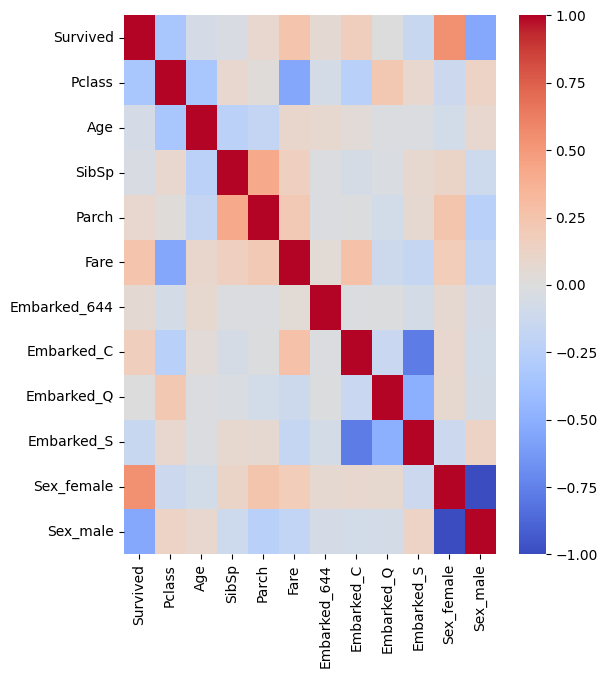

In [11]:
# Create a correlation heatmap

# drop the ID column... this will effect the visualization 
df1 = df.drop(columns= ['PassengerId']) # drop the ID column... this will effect the visualization 

# Create boolean columns for categorical features 
df2 = pd.get_dummies(df[['Embarked', 'Sex',]])

# merge boolean dataframe with original
df1 = df1.merge(df2, left_index= True, right_index= True)

# compute correlation matrix for numeric values only 
corr = df1.select_dtypes(include = ['number', 'bool']).corr() # grab all numbers and boolean columns and store into corr object

# create map
plt.figure(figsize= (6,7)) # visualization size 
sns.heatmap(corr, annot = False, cmap= 'coolwarm', fmt = '.2f' ) # correation matrix plot 

In [12]:
# numeric correlation
df1.corr(numeric_only= True)

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
Survived,1.000000,-0.338481,-0.067814,-0.035322,0.081629,0.257307,0.060095,0.168240,0.003650,-0.155660,0.543351,-0.543351
Pclass,-0.338481,1.000000,-0.334974,0.083081,0.018443,-0.549500,-0.074282,-0.243292,0.221009,0.081720,-0.131900,0.131900
Age,-0.067814,-0.334974,1.000000,-0.232978,-0.176486,0.093706,0.074589,0.031303,-0.021093,-0.021999,-0.082949,0.082949
SibSp,-0.035322,0.083081,-0.232978,1.000000,0.414838,0.159651,-0.022508,-0.059528,-0.026354,0.070941,0.114631,-0.114631
Parch,0.081629,0.018443,-0.176486,0.414838,1.000000,0.216225,-0.022467,-0.011069,-0.081228,0.063036,0.245489,-0.245489
Fare,0.257307,-0.549500,0.093706,0.159651,0.216225,1.000000,0.045646,0.269335,-0.117216,-0.166603,0.182333,-0.182333
Embarked_644,0.060095,-0.074282,0.074589,-0.022508,-0.022467,0.045646,1.000000,-0.022864,-0.014588,-0.076588,0.064296,-0.064296
Embarked_C,0.168240,-0.243292,0.031303,-0.059528,-0.011069,0.269335,-0.022864,1.000000,-0.148258,-0.778359,0.082853,-0.082853
Embarked_Q,0.003650,0.221009,-0.021093,-0.026354,-0.081228,-0.117216,-0.014588,-0.148258,1.000000,-0.496624,0.074115,-0.074115
Embarked_S,-0.155660,0.081720,-0.021999,0.070941,0.063036,-0.166603,-0.076588,-0.778359,-0.496624,1.000000,-0.125722,0.125722


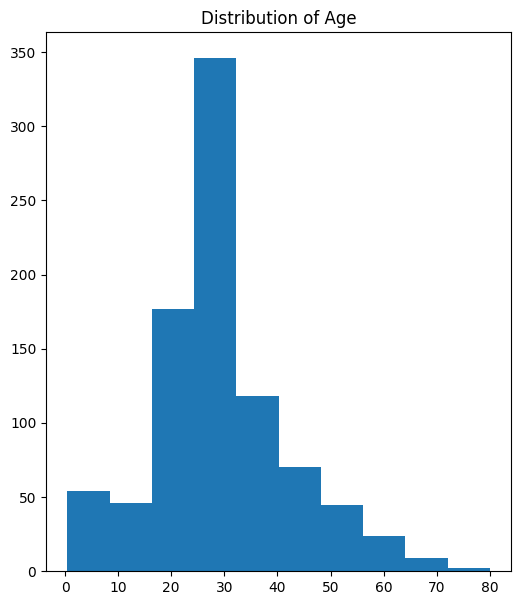

In [13]:
# distrbution of age 
plt.figure(figsize=(6,7))
plt.hist(x= df['Age'], density= False, )
plt.title('Distribution of Age')
plt.show() 

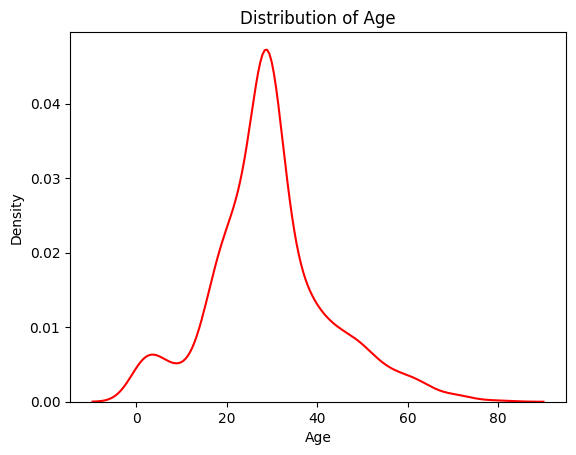

In [14]:
# Distribution of Age with smooth =
sns.kdeplot(data = df1, x = 'Age', color= 'red')
plt.title('Distribution of Age')
plt.show()

In [15]:
df1 

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,0,3,male,22.0,1,0,A/5 21171,7.2500,Unknown,S,False,False,False,True,False,True
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,False,True,False,False,True,False
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,False,False,False,True,True,False
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,False,False,False,True,True,False
4,0,3,male,35.0,0,0,373450,8.0500,Unknown,S,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,Unknown,S,False,False,False,True,False,True
887,1,1,female,19.0,0,0,112053,30.0000,B42,S,False,False,False,True,True,False
888,0,3,female,29.0,1,2,W./C. 6607,23.4500,Unknown,S,False,False,False,True,True,False
889,1,1,male,26.0,0,0,111369,30.0000,C148,C,False,True,False,False,False,True


<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

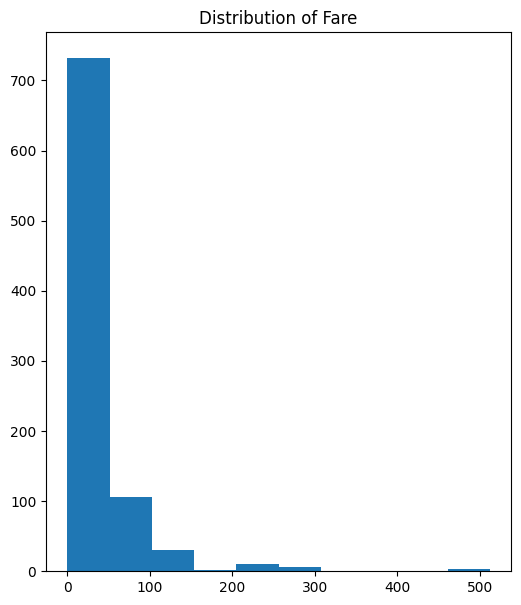

In [16]:
# Distribution of Fare (Passenger Price)
plt.figure(figsize=(6,7)) 
plt.hist(x = df1['Fare'], density= False)
plt.title('Distribution of Fare')
plt.title

<Axes: xlabel='Fare', ylabel='Density'>

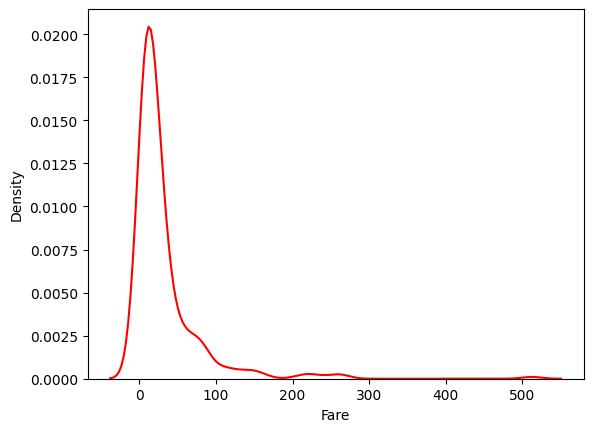

In [17]:
# Distribution of Fare with smoothing 
sns.kdeplot(df1, x = 'Fare', color = 'red')

In [18]:
df1

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,0,3,male,22.0,1,0,A/5 21171,7.2500,Unknown,S,False,False,False,True,False,True
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,False,True,False,False,True,False
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,False,False,False,True,True,False
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,False,False,False,True,True,False
4,0,3,male,35.0,0,0,373450,8.0500,Unknown,S,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,Unknown,S,False,False,False,True,False,True
887,1,1,female,19.0,0,0,112053,30.0000,B42,S,False,False,False,True,True,False
888,0,3,female,29.0,1,2,W./C. 6607,23.4500,Unknown,S,False,False,False,True,True,False
889,1,1,male,26.0,0,0,111369,30.0000,C148,C,False,True,False,False,False,True


In [19]:
# Turn high cardinality into meaningful patterns (Model can learn the importance of different categories based on mean )

# bring in scikit-learn
from sklearn.preprocessing import TargetEncoder

# intialize encoder (Including cross validation prohibits data leakage)
encoder = TargetEncoder(smooth = 'auto', cv = 5, shuffle= True, random_state = 42)

# store target variable and feature into X and Y
X = df1[['Cabin']]
Y = df1['Survived']

# fit and transform 
df1['cabin_encoded'] = encoder.fit_transform(X,Y)



In [20]:
df1

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,cabin_encoded
0,0,3,male,22.0,1,0,A/5 21171,7.2500,Unknown,S,False,False,False,True,False,True,0.303217
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,False,True,False,False,True,False,0.382889
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,False,False,False,True,True,False,0.298863
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,False,False,False,True,True,False,0.000000
4,0,3,male,35.0,0,0,373450,8.0500,Unknown,S,False,False,False,True,False,True,0.303215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,Unknown,S,False,False,False,True,False,True,0.297779
887,1,1,female,19.0,0,0,112053,30.0000,B42,S,False,False,False,True,True,False,0.384292
888,0,3,female,29.0,1,2,W./C. 6607,23.4500,Unknown,S,False,False,False,True,True,False,0.298863
889,1,1,male,26.0,0,0,111369,30.0000,C148,C,False,True,False,False,False,True,0.384292


In [21]:
# check the value count of the Embarked column 
df1['Embarked'].value_counts

<bound method IndexOpsMixin.value_counts of 0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object>

In [23]:
# Turn Embarked category into meaningful patterns (Downstream model will be able to recongnize importance of feature)

X1 = df1[['Embarked']] # independent variable
Y1 = df['Survived']   # dependent variable

# fit and transform column
df1['Emarked_encoded'] = encoder.fit_transform(X1,Y1)

In [32]:
df1['Ticket'].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
392091             1
Name: count, Length: 681, dtype: int64

In [ ]:
# Turn Ticket Number into a meaningful column using target encoder


Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
392091             1
Name: count, Length: 681, dtype: int64